# Uber Ride Bookings: Exploratory Data Analysis (EDA)

*An end-to-end exploratory analysis of 150,000 ride bookings: booking outcomes, cancellations, demand patterns, vehicle types, locations, pricing, ratings and payments.*

**Tools:** Python · pandas · NumPy · Matplotlib · Seaborn · Jupyter Notebook

---

**Contents**

2. Project Overview
3. Business Questions / Objectives
4. Dataset Overview
5. Import Libraries
6. Load Dataset
7. Data Understanding
8. Data Quality Analysis
9. Feature Engineering
10. Booking Status Analysis
11. Cancellation Analysis
12. Time-Based Analysis
13. Vehicle Analysis
14. Location Analysis
15. Numerical Variable Analysis
16. Payment Method Analysis
17. Correlation Analysis
18. Outlier Analysis
19. Key Insights
20. Machine Learning Considerations
21. Conclusion

## 2. Project Overview

This project analyses a dataset of 150,000 ride bookings made during 2024. Each record describes one booking: when it was made, the vehicle type, pickup and drop locations, how the booking ended, and (where applicable) the fare, distance, ratings, payment method and reasons for cancellation.

The aim is to understand **how bookings end**, **why rides fail**, and **how demand, pricing, ratings and payments behave** across time, vehicle types and locations.

**Approach**

1. Understand the structure of the data and assess its quality.
2. Engineer time-based features from the booking timestamp.
3. Analyse booking outcomes, cancellations, time patterns, vehicles, locations, numerical variables and payments.
4. Examine correlations and outliers.
5. Summarise key insights and discuss considerations for a future machine learning task.

*Note: this is a descriptive analysis. Patterns and associations reported here do not by themselves establish cause and effect.*

## 3. Business Questions / Objectives

1. What proportion of bookings are completed, and how do the unsuccessful bookings break down?
2. How often and why do drivers and customers cancel? Do cancellation rates change by vehicle type, hour or day?
3. When is demand highest (hour of day, weekday vs. weekend, month)?
4. Do vehicle types differ in booking outcomes, booking value, distance or ratings?
5. Which pickup locations, drop locations and routes are most frequent, and do outcomes differ across them?
6. How are Booking Value, Ride Distance, Avg VTAT, Avg CTAT and ratings distributed, and how are they related?
7. Which payment methods are used, and are they related to booking value or ride completion?
8. Which variables could be used to predict Booking Status, and which would cause data leakage?

## 4. Dataset Overview

**Source file:** `ncr_ride_bookings.csv` (150,000 rows × 21 columns)

| Column | Description |
|---|---|
| `Date`, `Time` | Date and time of the booking |
| `Booking ID`, `Customer ID` | Booking and customer identifiers |
| `Booking Status` | Final outcome of the booking (5 categories) |
| `Vehicle Type` | Type of vehicle requested (7 categories) |
| `Pickup Location`, `Drop Location` | Pickup and drop-off locations (176 unique values each) |
| `Avg VTAT` | Average vehicle arrival time to the pickup point, in minutes (interpreted from the column name) |
| `Avg CTAT` | Average ride time, in minutes (interpreted from the column name) |
| `Cancelled Rides by Customer`, `Reason for cancelling by Customer` | Flag and reason for customer cancellations |
| `Cancelled Rides by Driver`, `Driver Cancellation Reason` | Flag and reason for driver cancellations |
| `Incomplete Rides`, `Incomplete Rides Reason` | Flag and reason for incomplete rides |
| `Booking Value` | Value of the booking (₹) |
| `Ride Distance` | Distance of the ride (unit not specified in the data) |
| `Driver Ratings`, `Customer Rating` | Ratings recorded for the ride |
| `Payment Method` | Payment method used |

*Column descriptions are based on column names and observed values. Where the dataset does not state a definition or unit, it is noted above.*

## 5. Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 6. Load Dataset

The CSV file is expected in the same folder as this notebook.

In [2]:
df = pd.read_csv("ncr_ride_bookings.csv")

In [3]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## 7. Data Understanding

Before any analysis, the dataset's size, column types and basic statistics are reviewed.

### 7.1 Shape and structure

In [4]:
df.shape

(150000, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

### 7.2 Summary statistics

In [6]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [7]:
df.describe(include=object)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,150000,10500,27000,9000,102000
unique,365,62910,148767,5,148788,7,176,176,5,4,3,5
top,2024-11-16,17:44:57,"""CNR7908610""",Completed,"""CID4523979""",Auto,Khandsa,Ashram,Wrong Address,Customer related issue,Customer Demand,UPI
freq,462,16,3,93000,3,37419,949,936,2362,6837,3040,45909


> **Insight:** - The dataset has **150,000 rows and 21 columns** (12 text/object columns and 9 numeric columns).
- `Date` and `Time` are stored as text, so they are converted to proper datetime features in the Feature Engineering section.
- Numeric ranges: Booking Value ₹50 to ₹4,277, Ride Distance 1 to 50, Avg VTAT 2 to 20, Avg CTAT 10 to 45, and both rating columns 3.0 to 5.0.
- The `count` row differs across columns (for example 139,500 for Avg VTAT, 102,000 for Booking Value and 93,000 for ratings). This points to missing values that are examined next.
- The data covers 365 unique dates, 7 vehicle types and 176 unique pickup and drop locations.

## 8. Data Quality Analysis

This section checks missing values and duplicates, and decides how they should be handled before analysis.

### 8.1 Missing values

In [8]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [9]:
df.isnull().mean()*100

Date                                  0.0
Time                                  0.0
Booking ID                            0.0
Booking Status                        0.0
Customer ID                           0.0
Vehicle Type                          0.0
Pickup Location                       0.0
Drop Location                         0.0
Avg VTAT                              7.0
Avg CTAT                             32.0
Cancelled Rides by Customer          93.0
Reason for cancelling by Customer    93.0
Cancelled Rides by Driver            82.0
Driver Cancellation Reason           82.0
Incomplete Rides                     94.0
Incomplete Rides Reason              94.0
Booking Value                        32.0
Ride Distance                        32.0
Driver Ratings                       38.0
Customer Rating                      38.0
Payment Method                       32.0
dtype: float64

### 8.2 Is the missingness random or structural?

Many columns have a large share of missing values. To check whether this is random or follows a pattern, the number of **non-missing** values in key columns is counted for each Booking Status.

In [10]:
df.groupby("Booking Status")[
    ["Booking Value", "Ride Distance", "Avg VTAT", "Avg CTAT",
     "Driver Ratings", "Customer Rating", "Payment Method"]
].count()

,Booking Value,Ride Distance,Avg VTAT,Avg CTAT,Driver Ratings,Customer Rating,Payment Method
Booking Status,,,,,,,
Cancelled by Customer,0,0,10500,0,0,0,0
Cancelled by Driver,0,0,27000,0,0,0,0
Completed,93000,93000,93000,93000,93000,93000,93000
Incomplete,9000,9000,9000,9000,0,0,9000
No Driver Found,0,0,0,0,0,0,0


Combining this with the reason columns (explored in the Cancellation section), the pattern is:

| Column(s) | Populated only for |
|---|---|
| `Reason for cancelling by Customer`, `Cancelled Rides by Customer` | Cancelled by Customer (10,500) |
| `Driver Cancellation Reason`, `Cancelled Rides by Driver` | Cancelled by Driver (27,000) |
| `Incomplete Rides Reason`, `Incomplete Rides` | Incomplete (9,000) |
| `Driver Ratings`, `Customer Rating` | Completed (93,000) |
| `Booking Value`, `Ride Distance`, `Avg CTAT`, `Payment Method` | Completed and Incomplete (102,000) |
| `Avg VTAT` | All statuses except No Driver Found (139,500) |

> **Insight:** - **Missing values are structural, not random.** They depend on how the booking ended. For example, a ride that was never completed has no rating, and a booking where no driver was found has no fare, distance or payment method.
- Because the missing values carry meaning, they are **not imputed or dropped**. Each analysis uses the non-missing values that are relevant to it.

### 8.3 Duplicate records

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Booking ID"].duplicated().sum()

np.int64(1233)

In [13]:
df[df["Booking ID"].duplicated(keep=False)].sort_values("Booking ID").head(20)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
81334,2024-10-15,18:17:23,"""CNR1026036""",Completed,"""CID6480133""",Go Mini,Khandsa,Ashok Vihar,3.8,43.3,...,NaN,NaN,NaN,NaN,NaN,102.0,36.51,4.9,4.2,UPI
9192,2024-07-21,17:59:41,"""CNR1026036""",No Driver Found,"""CID6974869""",Go Mini,Seelampur,Nehru Place,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9587,2024-12-17,19:19:02,"""CNR1029172""",Completed,"""CID6382731""",Auto,Inderlok,Laxmi Nagar,6.9,34.4,...,NaN,NaN,NaN,NaN,NaN,332.0,36.38,4.3,4.3,UPI
1353,2024-01-19,17:00:57,"""CNR1029172""",Incomplete,"""CID2615731""",Bike,Jhilmil,Narsinghpur,4.7,26.7,...,NaN,NaN,NaN,1.0,Customer Demand,429.0,16.16,NaN,NaN,UPI
82029,2024-11-05,16:50:20,"""CNR1051228""",Completed,"""CID3177617""",Auto,Dwarka Sector 21,Nehru Place,8.5,24.8,...,NaN,NaN,NaN,NaN,NaN,246.0,4.80,4.6,4.5,UPI
110412,2024-01-31,08:42:04,"""CNR1051228""",Completed,"""CID5242056""",Premier Sedan,Arjangarh,Yamuna Bank,14.2,25.4,...,NaN,NaN,NaN,NaN,NaN,930.0,13.06,3.4,4.2,Cash
87333,2024-04-20,23:16:21,"""CNR1056023""",Completed,"""CID9367665""",Premier Sedan,Badshahpur,Sultanpur,7.1,25.7,...,NaN,NaN,NaN,NaN,NaN,116.0,46.54,3.8,5.0,Credit Card
120008,2024-07-07,17:18:49,"""CNR1056023""",Incomplete,"""CID4890470""",Go Sedan,Meerut,Tilak Nagar,6.6,24.2,...,NaN,NaN,NaN,1.0,Customer Demand,420.0,5.13,NaN,NaN,Uber Wallet
71570,2024-02-12,19:02:47,"""CNR1058956""",Cancelled by Customer,"""CID2451799""",Premier Sedan,Patel Chowk,Kaushambi,19.9,NaN,...,Wrong Address,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38548,2024-10-15,13:33:55,"""CNR1058956""",Completed,"""CID1882606""",Go Mini,Badshahpur,MG Road,3.7,20.2,...,NaN,NaN,NaN,NaN,NaN,194.0,24.65,4.3,4.3,Cash


> **Insight:** - **No completely duplicated rows** were found.
- However, **1,233 Booking IDs appear more than once** (148,767 unique IDs across 150,000 rows). The sample above shows the same Booking ID attached to different dates, customers, vehicles and outcomes, so these rows are not duplicate records of the same booking.
- All rows are therefore retained and each row is treated as a separate booking. The repeated IDs are flagged as a data-quality issue that should be confirmed with the data owner.

## 9. Feature Engineering

Time-based features are created from the booking timestamp so that demand and outcomes can be analysed by hour, day and month.

| New feature | Description |
|---|---|
| `DateTime` | Date and time combined into one timestamp |
| `Hour` | Hour of the day (0–23) |
| `DayOfWeek` | Name of the weekday |
| `Month` | Name of the month |
| `Day_Type` | Weekday or Weekend |

In [14]:
# Combine Date and Time into a single timestamp
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

# Extract the hour of day and the day of the week
df["Hour"] = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.day_name()

In [15]:
# Convert Date to datetime and extract the month name
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month_name()

# Label each booking as Weekday or Weekend
df["Day_Type"] = df["DayOfWeek"].isin(["Saturday", "Sunday"]).map({True: "Weekend", False: "Weekday"})

In [16]:
df[["DateTime","DayOfWeek","Hour"]].head()

,DateTime,DayOfWeek,Hour
0,2024-03-23 12:29:38,Saturday,12
1,2024-11-29 18:01:39,Friday,18
2,2024-08-23 08:56:10,Friday,8
3,2024-10-21 17:17:25,Monday,17
4,2024-09-16 22:08:00,Monday,22


In [17]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'DateTime',
       'Hour', 'DayOfWeek', 'Month', 'Day_Type'],
      dtype='object')

> **Insight:** Five new columns (`DateTime`, `Hour`, `DayOfWeek`, `Month`, `Day_Type`) were added without changing any existing values. A ride-distance band (`Distance_Bin`) is created later, in the Correlation Analysis section.

## 10. Booking Status Analysis

The first question is how bookings end. Booking Status has five categories: Completed, Cancelled by Driver, Cancelled by Customer, No Driver Found and Incomplete.

### 10.1 Overall booking status distribution

In [18]:
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [19]:
df["Booking Status"].value_counts(normalize=True)*100

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64

> **Insight:** - **62% of bookings were completed** (93,000 of 150,000).
- **38% (57,000 bookings) did not result in a completed ride:**
  - **18%** were cancelled by drivers (27,000)
  - **7%** were cancelled by customers (10,500)
  - **7%** had no driver found (10,500)
  - **6%** were incomplete (9,000)
- Driver cancellations are the single largest cause of unsuccessful bookings, accounting for nearly half of them.

### 10.2 Reasons for incomplete rides

In [20]:
df["Incomplete Rides Reason"].value_counts()

Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
Name: count, dtype: int64

In [21]:
incomplete_reason_pct = (
    df["Incomplete Rides Reason"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

incomplete_reason_pct

Incomplete Rides Reason
Customer Demand      33.78
Vehicle Breakdown    33.47
Other Issue          32.76
Name: proportion, dtype: float64

> **Insight:** Incomplete rides are split almost evenly across the three recorded reasons: Customer Demand (33.78%), Vehicle Breakdown (33.47%) and Other Issue (32.76%). No single reason dominates.

## 11. Cancellation Analysis

Cancellations are the biggest reason bookings fail. This section looks at how many there are, why they happen, when they happen, and how they relate to pickup time.

### 11.1 Cancellation volume

In [22]:
df["Booking Status"].value_counts().loc[
    ["Cancelled by Customer", "Cancelled by Driver"]
]

Booking Status
Cancelled by Customer    10500
Cancelled by Driver      27000
Name: count, dtype: int64

In [23]:
customer_cancelled = (df["Booking Status"] == "Cancelled by Customer").sum()

total_bookings = len(df)

customer_cancel_rate = (
    customer_cancelled / total_bookings * 100
)

print("Customer Cancelled Bookings:", customer_cancelled)
print("Customer Cancellation Rate:", round(customer_cancel_rate, 2), "%")


Customer Cancelled Bookings: 10500
Customer Cancellation Rate: 7.0 %


> **Insight:** - Drivers cancelled **27,000** bookings and customers cancelled **10,500**.
- Together, cancellations make up **25% of all bookings** (18% driver + 7% customer). Drivers account for roughly 72% of them, about 2.6 times as many as customers.

### 11.2 Why do customers cancel?

In [24]:
df["Reason for cancelling by Customer"].value_counts()

Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64

In [25]:
customer_cancelled = df[
    df["Booking Status"] == "Cancelled by Customer"
]

customer_cancelled["Reason for cancelling by Customer"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .round(2)

Reason for cancelling by Customer
Wrong Address                                   22.50
Change of plans                                 22.41
Driver is not moving towards pickup location    22.24
Driver asked to cancel                          21.86
AC is not working                               11.00
Name: proportion, dtype: float64

> **Insight:** - Four reasons are almost equally common, each around 22% of customer cancellations: Wrong Address (22.50%), Change of plans (22.41%), Driver is not moving towards pickup location (22.24%) and Driver asked to cancel (21.86%).
- AC is not working is less common (11.00%).
- Two of the five reasons relate to driver behaviour (driver not moving towards pickup, driver asked to cancel). Together they make up about 44% of customer cancellations.

### 11.3 Why do drivers cancel?

In [26]:
df["Driver Cancellation Reason"].value_counts(dropna=False)

Driver Cancellation Reason
NaN                                    123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64

In [27]:
driver_cancelled = df[
    df["Booking Status"] == "Cancelled by Driver"
]

driver_cancelled["Driver Cancellation Reason"] \
    .value_counts(normalize=True) \
    .mul(100) \
    .round(2)

Driver Cancellation Reason
Customer related issue                 25.32
The customer was coughing/sick         25.00
Personal & Car related issues          24.91
More than permitted people in there    24.76
Name: proportion, dtype: float64

> **Insight:** Driver cancellation reasons are also evenly distributed: Customer related issue (25.32%), The customer was coughing/sick (25.00%), Personal & Car related issues (24.91%) and More than permitted people in there (24.76%). No single reason stands out.

### 11.4 When do cancellations happen?

**Overall cancellation rate (customer + driver) by hour**

In [28]:
hour_cancellation_rate = (
    df["Booking Status"]
    .isin(["Cancelled by Customer", "Cancelled by Driver"])
    .groupby(df["Hour"])
    .mean()
    .mul(100)
    .round(2)
)

hour_cancellation_rate

Hour
0     24.76
1     25.29
2     22.18
3     25.67
4     25.59
5     26.42
6     24.16
7     25.36
8     24.98
9     24.91
10    24.90
11    24.05
12    24.74
13    25.25
14    26.08
15    25.68
16    24.52
17    24.89
18    25.38
19    25.53
20    24.59
21    23.98
22    25.57
23    25.42
Name: Booking Status, dtype: float64

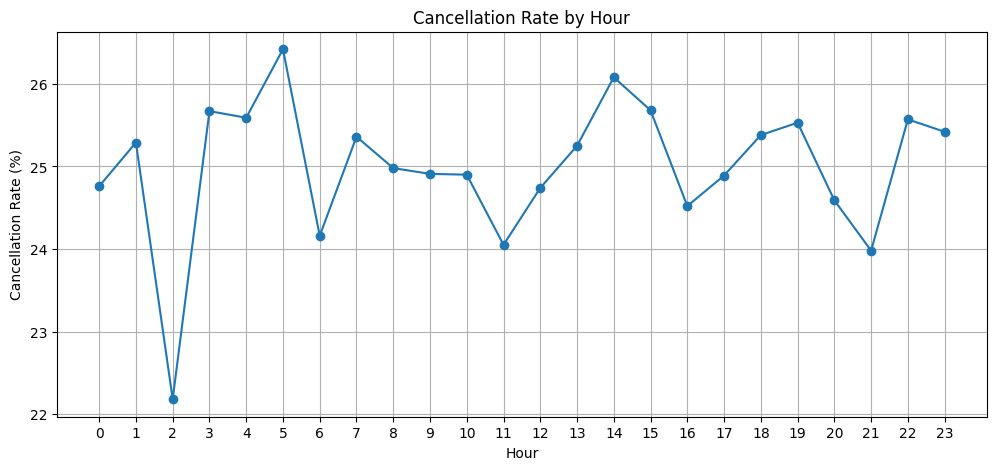

In [29]:
plt.figure(figsize=(12, 5))

hour_cancellation_rate.plot(kind="line", marker="o")

plt.title("Cancellation Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(range(24))
plt.grid()
plt.show()

**Customer and driver cancellation rates by hour**

In [30]:
customer_cancel_hour = (
    (df["Booking Status"] == "Cancelled by Customer")
    .groupby(df["Hour"])
    .mean()
    .mul(100)
    .round(2)
)

customer_cancel_hour

Hour
0     6.70
1     6.91
2     5.60
3     6.65
4     7.42
5     7.32
6     7.36
7     6.90
8     7.19
9     6.79
10    7.00
11    6.64
12    6.84
13    6.95
14    7.44
15    7.73
16    6.58
17    6.75
18    7.17
19    7.44
20    6.57
21    6.76
22    6.98
23    7.82
Name: Booking Status, dtype: float64

In [31]:
driver_cancel_hour = (
    (df["Booking Status"] == "Cancelled by Driver")
    .groupby(df["Hour"])
    .mean()
    .mul(100)
    .round(2)
)

driver_cancel_hour

Hour
0     18.06
1     18.38
2     16.58
3     19.02
4     18.17
5     19.10
6     16.80
7     18.46
8     17.80
9     18.12
10    17.91
11    17.41
12    17.90
13    18.30
14    18.65
15    17.95
16    17.94
17    18.14
18    18.21
19    18.09
20    18.02
21    17.22
22    18.58
23    17.60
Name: Booking Status, dtype: float64

**Cancellation rates by day of the week**

In [32]:
day_cancellation_rate = (
    df["Booking Status"]
    .isin(["Cancelled by Customer", "Cancelled by Driver"])
    .groupby(df["DayOfWeek"])
    .mean()
    .mul(100)
    .round(2)
)

day_cancellation_rate


DayOfWeek
Friday       24.97
Monday       25.65
Saturday     24.73
Sunday       24.97
Thursday     24.66
Tuesday      25.19
Wednesday    24.82
Name: Booking Status, dtype: float64

In [33]:
customer_cancel_day = (
    (df["Booking Status"] == "Cancelled by Customer")
    .groupby(df["DayOfWeek"])
    .mean()
    .mul(100)
    .round(2)
)

customer_cancel_day

DayOfWeek
Friday       7.32
Monday       6.98
Saturday     6.75
Sunday       7.05
Thursday     6.97
Tuesday      6.87
Wednesday    7.07
Name: Booking Status, dtype: float64

In [34]:
driver_cancel_day = (
    (df["Booking Status"] == "Cancelled by Driver")
    .groupby(df["DayOfWeek"])
    .mean()
    .mul(100)
    .round(2)
)

driver_cancel_day

DayOfWeek
Friday       17.65
Monday       18.67
Saturday     17.98
Sunday       17.92
Thursday     17.69
Tuesday      18.32
Wednesday    17.76
Name: Booking Status, dtype: float64

> **Insight:** - The overall cancellation rate stays in a narrow band throughout the day: **22.18% (2 AM) to 26.42% (5 AM)**. By weekday it ranges only from 24.66% (Thursday) to 25.65% (Monday).
- Customer cancellation rates range from 5.60% to 7.82% by hour and 6.75% to 7.32% by weekday. Driver cancellation rates range from 16.58% to 19.10% by hour and 17.65% to 18.67% by weekday.
- There is no clear hour or day where cancellations spike. The overnight hours (0–4 AM) have only about 1,300–1,400 bookings per hour, so their rates fluctuate more and should not be over-interpreted.

### 11.5 Pickup time (Avg VTAT) and cancellations

The tables below compare Avg VTAT (vehicle arrival time) and other ride metrics across booking statuses, and across individual cancellation reasons.

In [35]:
df.groupby("Booking Status")[
    ["Avg VTAT", "Avg CTAT", "Booking Value", "Ride Distance"]
].agg(["count", "mean", "median"]).round(2)

Avg VTAT               Avg CTAT                \
                         count   mean median    count   mean median   
Booking Status                                                        
Cancelled by Customer    10500  12.51   12.6        0    NaN    NaN   
Cancelled by Driver      27000   7.50    7.5        0    NaN    NaN   
Completed                93000   8.51    8.5    93000  30.03   30.0   
Incomplete                9000   6.01    6.0     9000  20.00   20.0   
No Driver Found              0    NaN    NaN        0    NaN    NaN   

                      Booking Value                Ride Distance                
                              count    mean median         count   mean median  
Booking Status                                                                  
Cancelled by Customer             0     NaN    NaN             0    NaN    NaN  
Cancelled by Driver               0     NaN    NaN             0    NaN    NaN  
Completed                     93000  508.18  414.0         93000  26.00  26.02  
Incomplete                     9000  509.51  414.0          9000  10.55  10.54  
No Driver Found                   0     NaN    NaN             0    NaN    NaN

In [36]:
df.groupby("Reason for cancelling by Customer")["Avg VTAT"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Reason for cancelling by Customer,,,
AC is not working,1155,12.51,12.4
Change of plans,2353,12.45,12.5
Driver asked to cancel,2295,12.64,12.9
Driver is not moving towards pickup location,2335,12.57,12.6
Wrong Address,2362,12.40,12.3


In [37]:
df.groupby("Driver Cancellation Reason")["Avg VTAT"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Driver Cancellation Reason,,,
Customer related issue,6837,7.49,7.5
More than permitted people in there,6686,7.52,7.5
Personal & Car related issues,6726,7.46,7.5
The customer was coughing/sick,6751,7.54,7.5


> **Insight:** - **Customer-cancelled bookings had a longer average vehicle arrival time (12.51 min)** than completed bookings (8.51 min) and driver-cancelled bookings (7.50 min). This is consistent with customers cancelling when the wait is long, although the data alone cannot prove that waiting is the cause.
- Within each cancellation group, Avg VTAT is nearly identical across reasons (customer reasons: 12.40 to 12.64 min; driver reasons: 7.46 to 7.54 min), so the stated reason does not appear related to arrival time.
- Avg CTAT is recorded only for Completed (mean 30.03 min) and Incomplete (mean 20.00 min) rides.

## 12. Time-Based Analysis

This section examines when demand occurs (hour, weekday vs. weekend, month) and whether booking outcomes change over time.

### 12.1 Demand by hour of day

In [38]:
df["Hour"].value_counts().sort_index()

Hour
0      1373
1      1360
2      1339
3      1383
4      1321
5      2786
6      4160
7      5450
8      6861
9      8234
10     9577
11     8390
12     7006
13     5470
14     7031
15     8202
16     9633
17    11044
18    12397
19    11047
20     9630
21     8103
22     5441
23     2762
Name: count, dtype: int64

**Weekday vs. weekend demand by hour**

In [39]:
hour_day = df.groupby(["Hour", "Day_Type"]).size().unstack()
hour_day

Day_Type,Weekday,Weekend
Hour,,
0,978,395
1,967,393
2,983,356
3,989,394
4,927,394
5,2008,778
6,3001,1159
7,3880,1570
8,4915,1946


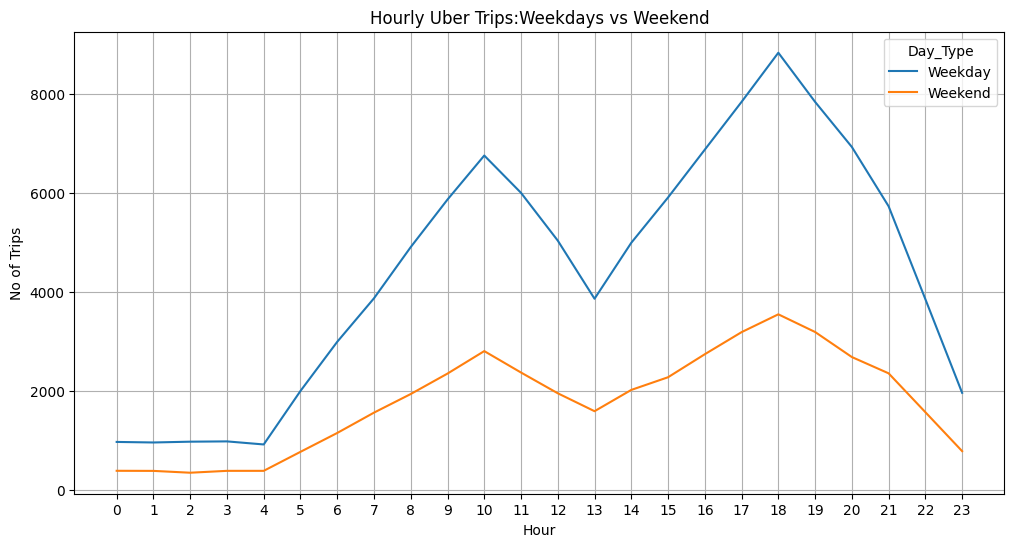

In [40]:
hour_day.plot(figsize=(12,6))
plt.title("Hourly Uber Trips:Weekdays vs Weekend")
plt.xlabel("Hour")
plt.ylabel("No of Trips")
plt.xticks(range(24))
plt.grid()
plt.show()

**Booking status by hour**

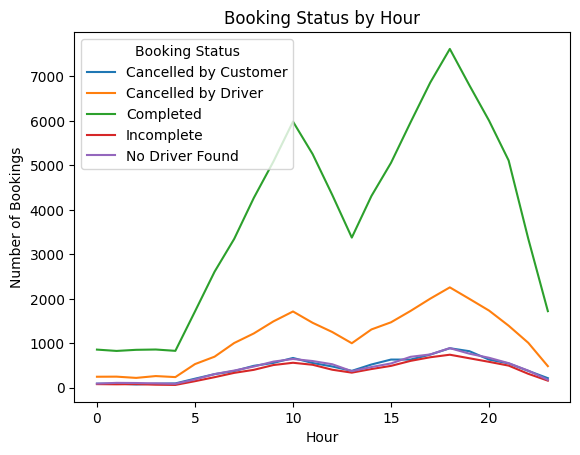

In [41]:
pd.crosstab(df["Hour"],df["Booking Status"]).plot(kind="line")
plt.title("Booking Status by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Bookings")
plt.show()

> **Insight:** - Demand follows a clear daily pattern with **two peaks**: a morning peak around 10:00 and a larger **evening peak at 18:00** (12,397 bookings, the highest of any hour).
- There is a midday dip at 13:00 (5,470 bookings) and very low demand overnight, with about 1,300–1,400 bookings per hour between 00:00 and 04:00.
- Weekdays and weekends have the **same hourly shape**; weekends simply have lower volume.
- The lines for each booking status rise and fall together, so peak hours have more completed *and* more failed bookings in proportion, not a worse outcome mix.

### 12.2 Demand by day of the week

In [42]:
df["DayOfWeek"].value_counts()

DayOfWeek
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Tuesday      21391
Thursday     21215
Name: count, dtype: int64

In [43]:
df["Day_Type"].value_counts()

Day_Type
Weekday    107060
Weekend     42940
Name: count, dtype: int64

In [44]:
df["Day_Type"].value_counts(normalize=True)*100

Day_Type
Weekday    71.373333
Weekend    28.626667
Name: proportion, dtype: float64

> **Insight:** - Bookings are spread almost evenly across the week: **21,215 (Thursday) to 21,644 (Monday)** per weekday name.
- Weekdays account for 107,060 bookings (71.4%) and weekends for 42,940 (28.6%). This is roughly in line with weekdays being 5 of 7 days (about 71.4%), so the average number of bookings **per day** is similar on weekdays and weekends.

### 12.3 Demand by month

In [45]:
df["Month"].value_counts()

Month
July         12897
January      12861
May          12778
March        12719
October      12651
August       12636
June         12440
November     12394
December     12250
September    12248
April        12199
February     11927
Name: count, dtype: int64

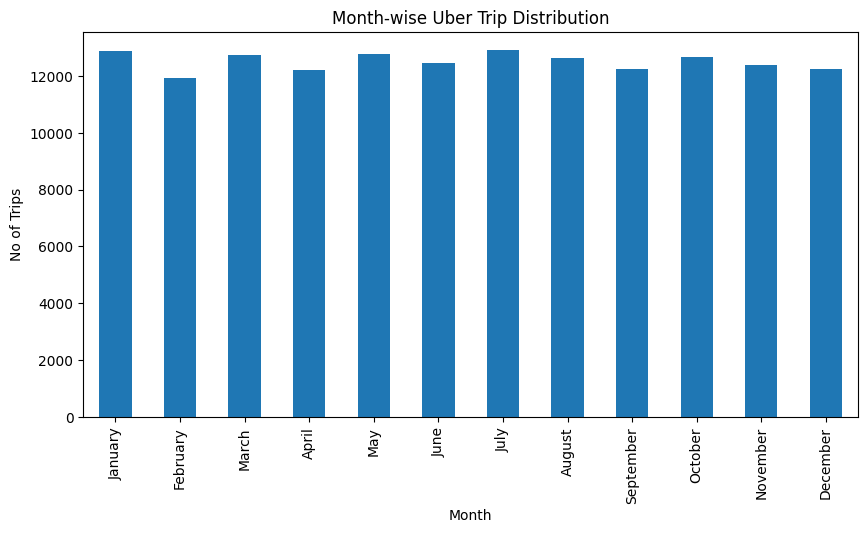

In [46]:
month_counts=df["Month"].value_counts().reindex([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
])
month_counts.plot(kind="bar",figsize=(10,5))
plt.title("Month-wise Uber Trip Distribution")
plt.xlabel("Month")
plt.ylabel("No of Trips")
plt.show()


> **Insight:** - Monthly volume is steady, ranging from **11,927 bookings (February)** to **12,897 (July)**.
- February is the lowest month, and it is also the shortest. There is no strong seasonal trend in this dataset.

### 12.4 Are booking outcomes stable over time?

**By month (% of bookings)**

In [47]:
month_status_pct = (
    pd.crosstab(
        df["Month"],
        df["Booking Status"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

month_status_pct

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Month,,,,,
April,6.39,18.21,62.56,5.94,6.90
August,6.60,18.61,61.57,5.82,7.41
December,7.05,18.04,62.21,5.89,6.81
February,7.03,18.36,61.78,5.71,7.13
January,6.94,18.07,61.82,6.28,6.88
July,7.23,18.08,61.46,6.23,7.01
June,7.10,17.73,62.36,5.93,6.88
March,7.12,17.61,62.54,5.72,7.01
May,7.19,18.13,61.86,6.01,6.80


**By day of the week (% of bookings)**

In [48]:
pd.crosstab(df["DayOfWeek"],df["Booking Status"],normalize="index").round(4)*100

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
DayOfWeek,,,,,
Friday,7.32,17.65,61.94,5.88,7.21
Monday,6.98,18.67,61.53,6.03,6.79
Saturday,6.75,17.98,62.40,5.97,6.89
Sunday,7.05,17.92,62.22,5.87,6.94
Thursday,6.97,17.69,62.25,6.10,6.99
Tuesday,6.87,18.32,61.57,6.23,7.01
Wednesday,7.07,17.76,62.09,5.92,7.17


**Weekday vs. weekend (% of bookings)**

In [49]:
daytype_status_pct = (
    pd.crosstab(
        df["Day_Type"],
        df["Booking Status"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

daytype_status_pct

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Day_Type,,,,,
Weekday,7.04,18.02,61.88,6.03,7.03
Weekend,6.90,17.95,62.31,5.92,6.92


> **Insight:** - Booking outcomes are **very stable over time**. The completion rate stays between 61.46% and 62.56% across months, between 61.53% and 62.40% across weekdays, and is 61.88% on weekdays vs. 62.31% on weekends.
- Driver cancellations stay close to 18% (17.58% to 18.61% by month) and customer cancellations close to 7% (6.39% to 7.30% by month).
- No month, weekday or weekend/weekday split shows a clear deterioration in service.

## 13. Vehicle Analysis

This section compares the seven vehicle types in terms of booking volume, booking outcomes, booking value, distance and ratings.

### 13.1 Booking volume by vehicle type

In [50]:
df["Vehicle Type"].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

> **Insight:** **Auto** is the most booked vehicle type (37,419 bookings, about 25% of the total), followed by Go Mini (about 20%), Go Sedan (about 18%) and Bike (about 15%). Premier Sedan (about 12%), eBike (about 7%) and Uber XL (about 3%) are the least booked.

### 13.2 Booking outcomes by vehicle type

In [51]:
vehicle_status=pd.crosstab(df["Vehicle Type"],df["Booking Status"])
vehicle_status

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Vehicle Type,,,,,
Auto,2680,6643,23155,2260,2681
Bike,1575,4077,14034,1328,1503
Go Mini,2097,5330,18549,1815,2015
Go Sedan,1832,5031,16676,1642,1960
Premier Sedan,1266,3250,11252,1063,1280
Uber XL,327,762,2783,262,315
eBike,723,1907,6551,630,746


In [52]:
vehicle_status_pct=pd.crosstab(df["Vehicle Type"],df["Booking Status"],normalize="index")*100
vehicle_status_pct

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Vehicle Type,,,,,
Auto,7.162137,17.753013,61.880328,6.039712,7.164809
Bike,6.994715,18.106320,62.326242,5.897766,6.674957
Go Mini,7.035496,17.882306,62.232436,6.089378,6.760384
Go Sedan,6.749936,18.536531,61.442099,6.049888,7.221547
Premier Sedan,6.990227,17.944895,62.127989,5.869361,7.067528
Uber XL,7.349966,17.127444,62.553383,5.888964,7.080243
eBike,6.848537,18.063844,62.053614,5.967604,7.066401


In [53]:
cancellation_rate = (
    df["Booking Status"]
    .isin(["Cancelled by Customer", "Cancelled by Driver"])
    .groupby(df["Vehicle Type"])
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

cancellation_rate


Vehicle Type
Go Sedan         25.29
Bike             25.10
Premier Sedan    24.94
Auto             24.92
Go Mini          24.92
eBike            24.91
Uber XL          24.48
Name: Booking Status, dtype: float64

> **Insight:** - Outcome percentages are **very similar across vehicle types**. The completion rate ranges from 61.44% (Go Sedan) to 62.55% (Uber XL), and driver cancellations from 17.13% (Uber XL) to 18.54% (Go Sedan).
- The overall cancellation rate ranges from 24.48% (Uber XL) to 25.29% (Go Sedan), a spread of less than one percentage point.
- Vehicle type does not appear to be a strong differentiator of booking outcome.

### 13.3 Booking value, distance and ratings by vehicle type

In [54]:
df.groupby("Vehicle Type")["Booking Value"].agg(["count","mean","median","min","max"]).round(2)

,count,mean,median,min,max
Vehicle Type,,,,,
Auto,25415,506.73,414.0,50.0,4220.0
Bike,15362,510.20,416.0,50.0,4228.0
Go Mini,20364,507.68,412.0,50.0,4277.0
Go Sedan,18318,511.50,416.0,50.0,4088.0
Premier Sedan,12315,509.57,416.0,50.0,4008.0
Uber XL,3045,501.82,406.0,50.0,3703.0
eBike,7181,503.90,410.0,50.0,4093.0


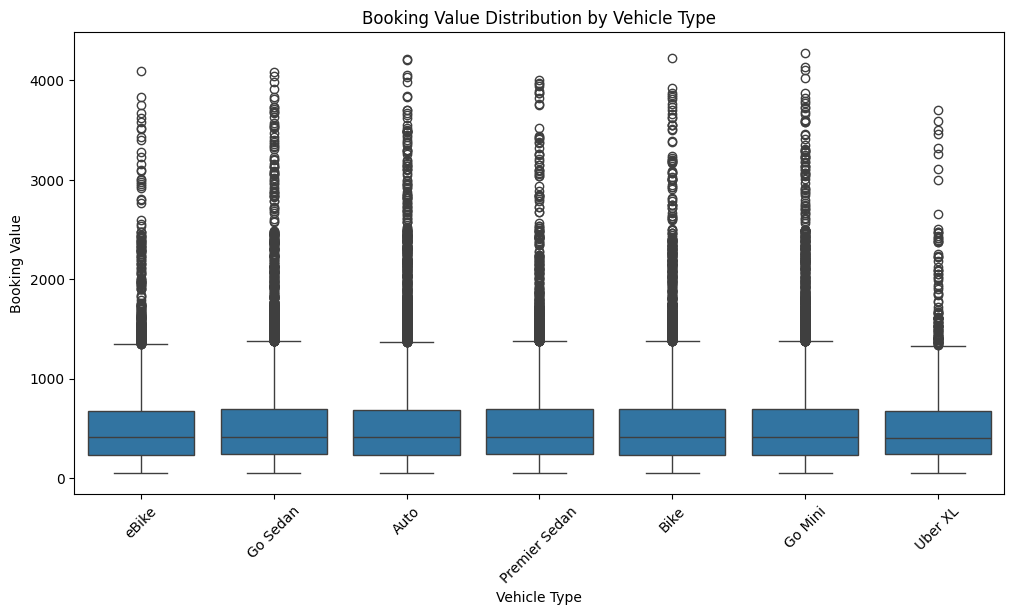

In [55]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Vehicle Type",
    y="Booking Value"
)

plt.title("Booking Value Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Booking Value")
plt.xticks(rotation=45)
plt.show()

In [56]:
df.groupby("Vehicle Type")["Ride Distance"].mean().sort_values(ascending=False)


Vehicle Type
eBike            24.990415
Bike             24.649546
Auto             24.615996
Go Mini          24.612090
Go Sedan         24.609325
Premier Sedan    24.598956
Uber XL          24.402893
Name: Ride Distance, dtype: float64

In [57]:
df.groupby("Vehicle Type")["Driver Ratings"].mean().sort_values(ascending=False)

Vehicle Type
Uber XL          4.238340
Premier Sedan    4.234865
Auto             4.232369
Go Sedan         4.231812
Bike             4.230056
Go Mini          4.227694
eBike            4.225614
Name: Driver Ratings, dtype: float64

In [58]:
df.groupby("Vehicle Type")["Customer Rating"].mean().sort_values(ascending=False)


Vehicle Type
Go Sedan         4.409996
Uber XL          4.404851
Go Mini          4.404297
eBike            4.403954
Bike             4.403940
Premier Sedan    4.403457
Auto             4.402000
Name: Customer Rating, dtype: float64

> **Insight:** - Average booking value is nearly the same for every vehicle type (**₹501.82 for Uber XL to ₹511.50 for Go Sedan**; medians ₹406 to ₹416). The boxplots confirm that the distributions look alike, including the long upper tail.
- Higher-category vehicles are **not priced noticeably higher** in this data. For example, Premier Sedan averages ₹509.57 and Auto ₹506.73.
- Average ride distance (24.40 to 24.99), driver ratings (4.226 to 4.238) and customer ratings (4.402 to 4.410) are also almost identical across vehicle types.

## 14. Location Analysis

This section looks at the most frequent pickup and drop locations, the outcomes at those locations, and the most frequent routes.

### 14.1 Most frequent pickup and drop locations

In [59]:
df["Pickup Location"].value_counts().head(10)

Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64

In [60]:
df["Drop Location"].value_counts().head(10)

Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Nehru Place           902
Name: count, dtype: int64

> **Insight:** The dataset contains 176 unique pickup and 176 unique drop locations. Demand is **spread very evenly**: the top 10 pickup locations have 907 to 949 bookings each (Khandsa is highest) and the top 10 drop locations have 902 to 936 (Ashram is highest). No single location dominates.

### 14.2 Booking outcomes at the top 10 pickup locations

In [61]:
top_pickups = df["Pickup Location"].value_counts().head(10).index

pd.crosstab(
    df[df["Pickup Location"].isin(top_pickups)]["Pickup Location"],
    df[df["Pickup Location"].isin(top_pickups)]["Booking Status"]
)

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Pickup Location,,,,,
AIIMS,60,176,562,57,63
Badarpur,72,159,567,61,62
Barakhamba Road,60,170,594,64,58
Dwarka Sector 21,57,170,565,54,68
Khandsa,57,169,600,62,61
Madipur,53,159,579,65,63
Mehrauli,59,165,574,46,71
Pataudi Chowk,65,150,556,56,80
Pragati Maidan,69,179,538,64,70


In [62]:
pd.crosstab(
    df[df["Pickup Location"].isin(top_pickups)]["Pickup Location"],
    df[df["Pickup Location"].isin(top_pickups)]["Booking Status"],
    normalize="index"
).mul(100).round(2)

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Pickup Location,,,,,
AIIMS,6.54,19.17,61.22,6.21,6.86
Badarpur,7.82,17.26,61.56,6.62,6.73
Barakhamba Road,6.34,17.97,62.79,6.77,6.13
Dwarka Sector 21,6.24,18.60,61.82,5.91,7.44
Khandsa,6.01,17.81,63.22,6.53,6.43
Madipur,5.77,17.30,63.00,7.07,6.86
Mehrauli,6.45,18.03,62.73,5.03,7.76
Pataudi Chowk,7.17,16.54,61.30,6.17,8.82
Pragati Maidan,7.50,19.46,58.48,6.96,7.61


### 14.3 Booking outcomes at the top 10 drop locations

In [63]:
top_drops = df["Drop Location"].value_counts().head(10).index

pd.crosstab(
    df[df["Drop Location"].isin(top_drops)]["Drop Location"],
    df[df["Drop Location"].isin(top_drops)]["Booking Status"]
)

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Drop Location,,,,,
Ashram,66,166,592,59,53
Basai Dhankot,66,192,544,55,60
Cyber Hub,67,151,571,52,71
Kalkaji,73,166,543,55,75
Kashmere Gate ISBT,54,166,570,50,69
Lajpat Nagar,54,161,572,54,63
Lok Kalyan Marg,69,165,560,53,69
Narsinghpur,57,166,574,57,59
Nehru Place,67,171,552,53,59


In [64]:
pd.crosstab(
    df[df["Drop Location"].isin(top_drops)]["Drop Location"],
    df[df["Drop Location"].isin(top_drops)]["Booking Status"],
    normalize="index"
).mul(100).round(2)

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Drop Location,,,,,
Ashram,7.05,17.74,63.25,6.30,5.66
Basai Dhankot,7.20,20.94,59.32,6.00,6.54
Cyber Hub,7.35,16.56,62.61,5.70,7.79
Kalkaji,8.00,18.20,59.54,6.03,8.22
Kashmere Gate ISBT,5.94,18.26,62.71,5.50,7.59
Lajpat Nagar,5.97,17.81,63.27,5.97,6.97
Lok Kalyan Marg,7.53,18.01,61.14,5.79,7.53
Narsinghpur,6.24,18.18,62.87,6.24,6.46
Nehru Place,7.43,18.96,61.20,5.88,6.54


> **Insight:** - Among the top 10 pickup locations, the completion rate ranges from 58.48% (Pragati Maidan) to 63.22% (Khandsa), and driver cancellations from 16.54% (Pataudi Chowk) to 19.46% (Pragati Maidan).
- Among the top 10 drop locations, Basai Dhankot has the highest driver cancellation rate (20.94%) and the lowest completion rate (59.32%), while Kalkaji has the highest customer cancellation rate (8.00%).
- Each location has fewer than about 1,000 bookings, so these percentages are less stable than the overall figures. Differences between locations should be treated as indicative rather than conclusive.

### 14.4 Most frequent routes

In [65]:
top_routes = (
    df.groupby(["Pickup Location", "Drop Location"])
      .size()
      .sort_values(ascending=False)
      .head(10)
)

top_routes

Pickup Location  Drop Location      
DLF City Court   Bhiwadi                17
Janakpuri        Faridabad Sector 15    16
Akshardham       RK Puram               16
Rithala          Udyog Vihar Phase 4    15
Ghaziabad        Badshahpur             15
Vatika Chowk     Rithala                15
Jor Bagh         Rohini East            15
South Extension  Gwal Pahari            14
Mayur Vihar      Vidhan Sabha           14
Connaught Place  Paharganj              14
dtype: int64

In [66]:
top_route_pairs = (
    df.groupby(["Pickup Location", "Drop Location"])
      .size()
      .sort_values(ascending=False)
      .head(10)
      .index
)

route_status = (
    df[df.set_index(["Pickup Location", "Drop Location"]).index.isin(top_route_pairs)]
    .groupby(["Pickup Location", "Drop Location", "Booking Status"])
    .size()
    .unstack(fill_value=0)
)

route_status

,Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Pickup Location,Drop Location,,,,,
Akshardham,RK Puram,3,2,7,2,2
Connaught Place,Paharganj,0,3,9,1,1
DLF City Court,Bhiwadi,0,1,13,1,2
Ghaziabad,Badshahpur,3,3,6,1,2
Janakpuri,Faridabad Sector 15,2,2,9,1,2
Jor Bagh,Rohini East,3,3,7,1,1
Mayur Vihar,Vidhan Sabha,0,4,10,0,0
Rithala,Udyog Vihar Phase 4,0,3,11,0,1
South Extension,Gwal Pahari,0,2,10,0,2


In [67]:
route_status_pct = (
    route_status
    .div(route_status.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

route_status_pct

,Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Pickup Location,Drop Location,,,,,
Akshardham,RK Puram,18.75,12.50,43.75,12.50,12.50
Connaught Place,Paharganj,0.00,21.43,64.29,7.14,7.14
DLF City Court,Bhiwadi,0.00,5.88,76.47,5.88,11.76
Ghaziabad,Badshahpur,20.00,20.00,40.00,6.67,13.33
Janakpuri,Faridabad Sector 15,12.50,12.50,56.25,6.25,12.50
Jor Bagh,Rohini East,20.00,20.00,46.67,6.67,6.67
Mayur Vihar,Vidhan Sabha,0.00,28.57,71.43,0.00,0.00
Rithala,Udyog Vihar Phase 4,0.00,20.00,73.33,0.00,6.67
South Extension,Gwal Pahari,0.00,14.29,71.43,0.00,14.29


> **Insight:** - Route-level data is **very sparse**. The most frequent route (DLF City Court to Bhiwadi) has only 17 bookings, and the top 10 routes have 14 to 17 bookings each.
- With so few bookings, percentages swing widely. For example, Vatika Chowk to Rithala shows 40% driver cancellations, but that is 6 of 15 bookings.
- Route-level results are therefore not reliable for drawing conclusions. Pickup and drop locations are better analysed separately.

## 15. Numerical Variable Analysis

Each numerical variable is summarised using descriptive statistics, its distribution and its skewness. Statistics use only non-missing values (see Section 8).

### 15.1 Booking Value

In [68]:
df["Booking Value"].describe().round(2)

count    102000.00
mean        508.30
std         395.81
min          50.00
25%         234.00
50%         414.00
75%         689.00
max        4277.00
Name: Booking Value, dtype: float64

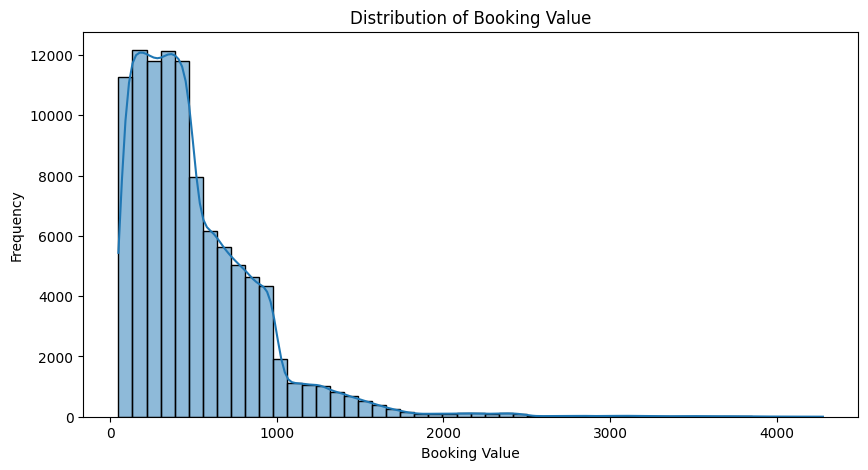

In [69]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Booking Value"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Booking Value")
plt.xlabel("Booking Value")
plt.ylabel("Frequency")
plt.show()

In [70]:
df["Booking Value"].skew()


np.float64(2.287351043950834)

> **Insight:** - Mean booking value is **₹508.30**, higher than the median of **₹414**, with a standard deviation of ₹395.81 and a range of ₹50 to ₹4,277.
- Skewness is **2.29**, so the distribution is strongly right-skewed: most bookings are below ₹1,000, with a long tail of high-value bookings that pulls the mean upward.
- The median is the better measure of a typical booking value.

### 15.2 Ride Distance

In [71]:
df["Ride Distance"].describe().round(2)

count    102000.00
mean         24.64
std          14.00
min           1.00
25%          12.46
50%          23.72
75%          36.82
max          50.00
Name: Ride Distance, dtype: float64

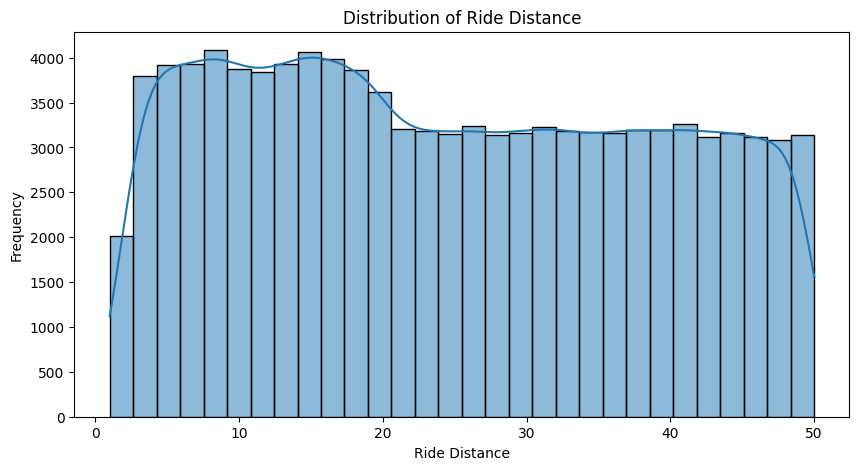

In [72]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Ride Distance"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Ride Distance")
plt.xlabel("Ride Distance")
plt.ylabel("Frequency")

plt.show()

In [73]:
df["Ride Distance"].skew()

np.float64(0.12831234313203943)

> **Insight:** - Mean ride distance is **24.64** and the median is 23.72, with values from 1 to 50.
- Skewness is **0.13**, so the distribution is close to symmetric. Distances are spread fairly evenly across the range, with somewhat higher frequency below about 20.

### 15.3 Avg VTAT

In [74]:
df["Avg VTAT"].describe()

count    139500.000000
mean          8.456352
std           3.773564
min           2.000000
25%           5.300000
50%           8.300000
75%          11.300000
max          20.000000
Name: Avg VTAT, dtype: float64

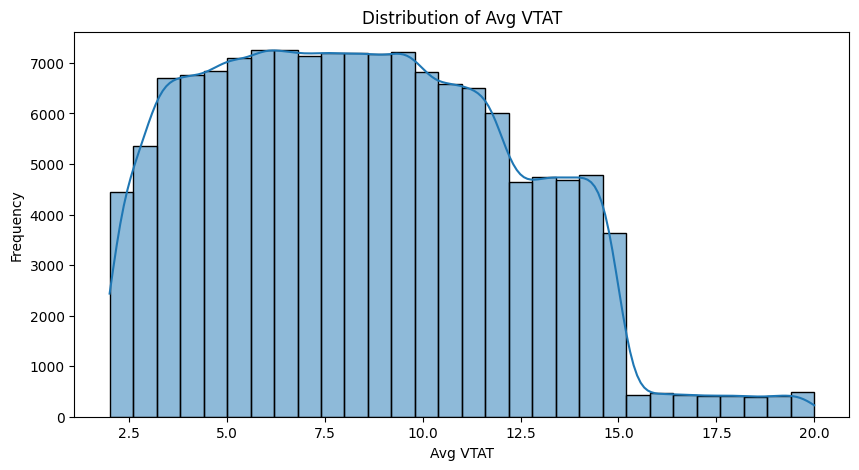

In [75]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Avg VTAT"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Avg VTAT")
plt.xlabel("Avg VTAT")
plt.ylabel("Frequency")

plt.show()

In [76]:
df["Avg VTAT"].skew()

np.float64(0.306564783909307)

> **Insight:** Avg VTAT has a mean of 8.46 minutes and a median of 8.3, ranging from 2 to 20 minutes. Skewness is 0.31 (mildly right-skewed). Most values fall between about 3 and 15 minutes, and frequency drops sharply beyond 15 minutes.

### 15.4 Avg CTAT

In [77]:
df["Avg CTAT"].describe()

count    102000.000000
mean         29.149636
std           8.902577
min          10.000000
25%          21.600000
50%          28.800000
75%          36.800000
max          45.000000
Name: Avg CTAT, dtype: float64

In [78]:
df["Avg CTAT"].skew()

np.float64(0.045899577394664985)

> **Insight:** Avg CTAT has a mean of 29.15 minutes and a median of 28.8, ranging from 10 to 45 minutes. Skewness is 0.05, so the distribution is essentially symmetric.

### 15.5 Driver Ratings

In [79]:
df["Driver Ratings"].describe()

count    93000.000000
mean         4.230992
std          0.436871
min          3.000000
25%          4.100000
50%          4.300000
75%          4.600000
max          5.000000
Name: Driver Ratings, dtype: float64

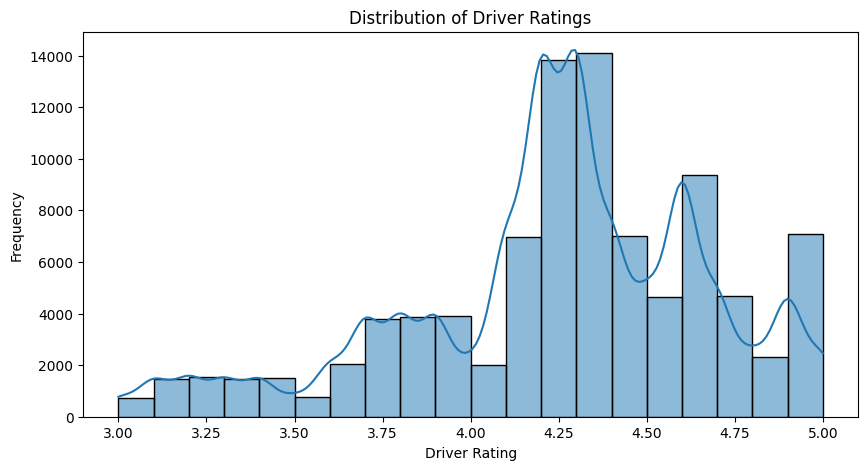

In [80]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Driver Ratings"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Driver Ratings")
plt.xlabel("Driver Rating")
plt.ylabel("Frequency")

plt.show()

In [81]:
df["Driver Ratings"].skew()

np.float64(-0.655715162927591)

> **Insight:** - Driver ratings average **4.23** (median 4.3) and range from 3.0 to 5.0. No rating below 3.0 exists in the data.
- Skewness is -0.66 (left-skewed): most ratings are concentrated between about 4.0 and 4.7, with fewer low ratings.

### 15.6 Customer Rating

In [82]:
df["Customer Rating"].describe()

count    93000.000000
mean         4.404584
std          0.437819
min          3.000000
25%          4.200000
50%          4.500000
75%          4.800000
max          5.000000
Name: Customer Rating, dtype: float64

In [83]:
df["Customer Rating"].value_counts().sort_index()

Customer Rating
3.0      468
3.1     1008
3.2      881
3.3      900
3.4      928
3.5      443
3.6     1194
3.7     2354
3.8     2357
3.9     2370
4.0     1185
4.1     5396
4.2    10697
4.3    10995
4.4     5279
4.5     5890
4.6    11533
4.7     5763
4.8     5880
4.9    11642
5.0     5837
Name: count, dtype: int64

In [84]:
df["Customer Rating"].skew()

np.float64(-0.885530681684472)

> **Insight:** - Customer ratings average **4.40** (median 4.5) and also range from 3.0 to 5.0.
- Skewness is -0.89, a stronger left skew than driver ratings. The value counts show the highest frequencies at 4.2, 4.3, 4.6 and 4.9.
- Customer Rating averages about 0.17 points higher than Driver Ratings (4.40 vs. 4.23).

### 15.7 Ride Distance by booking status

In [85]:
df.groupby("Booking Status")["Ride Distance"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Booking Status,,,,,,,,
Cancelled by Customer,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancelled by Driver,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Completed,93000.0,26.00,13.82,2.0,14.10,26.02,37.94,50.0
Incomplete,9000.0,10.55,5.43,1.0,5.97,10.54,15.17,20.0
No Driver Found,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> **Insight:** **Incomplete rides are much shorter** than completed rides. Incomplete rides average 10.55 in distance (maximum 20), while completed rides average 26.00 (range 2 to 50). Distance is recorded only for Completed and Incomplete bookings.

## 16. Payment Method Analysis

Payment Method is recorded only for Completed and Incomplete bookings (102,000 rows), so the percentages below refer to those bookings.

### 16.1 Payment method usage

In [86]:
df["Payment Method"].value_counts()

Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

In [87]:
df["Payment Method"].value_counts(normalize=True).mul(100).round(2)

Payment Method
UPI            45.01
Cash           24.87
Uber Wallet    12.04
Credit Card    10.01
Debit Card      8.08
Name: proportion, dtype: float64

> **Insight:** **UPI is the most used payment method (45.01%)**, followed by Cash (24.87%), Uber Wallet (12.04%), Credit Card (10.01%) and Debit Card (8.08%). Digital methods together account for roughly 75% of bookings.

### 16.2 Booking value by payment method

In [88]:
df.groupby("Payment Method")["Booking Value"].agg(["count","mean","median","min","max"]).round(2)

,count,mean,median,min,max
Payment Method,,,,,
Cash,25367,508.36,417.0,50.0,4133.0
Credit Card,10209,511.71,416.0,50.0,3985.0
Debit Card,8239,507.41,413.0,50.0,4228.0
UPI,45909,508.51,413.0,50.0,4277.0
Uber Wallet,12276,505.12,413.0,50.0,4202.0


> **Insight:** Booking value does not depend on the payment method. Mean booking value ranges from ₹505.12 (Uber Wallet) to ₹511.71 (Credit Card), and medians from ₹413 to ₹417.

### 16.3 Ride completion by payment method

In [89]:
pd.crosstab(
    df["Payment Method"],
    df["Booking Status"]
)

Booking Status,Completed,Incomplete
Payment Method,,
Cash,23114,2253
Credit Card,9320,889
Debit Card,7526,713
UPI,41834,4075
Uber Wallet,11206,1070


In [90]:
payment_status_pct = (
    pd.crosstab(
        df["Payment Method"],
        df["Booking Status"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

payment_status_pct

Booking Status,Completed,Incomplete
Payment Method,,
Cash,91.12,8.88
Credit Card,91.29,8.71
Debit Card,91.35,8.65
UPI,91.12,8.88
Uber Wallet,91.28,8.72


> **Insight:** The split between Completed and Incomplete is nearly identical for every payment method (about 91.1% to 91.4% completed and 8.6% to 8.9% incomplete). Payment method shows no meaningful association with whether a ride is completed. These percentages are higher for Incomplete than the overall 6% because they are calculated only on rides that have a payment record.

## 17. Correlation Analysis

Pearson correlation is used to check for linear relationships between the numerical variables. Values range from -1 to +1, and values near 0 indicate no linear relationship.

### 17.1 Booking Value vs. Ride Distance

In [91]:
df[["Booking Value", "Ride Distance"]].corr()

,Booking Value,Ride Distance
Booking Value,1.000000,0.005174
Ride Distance,0.005174,1.000000


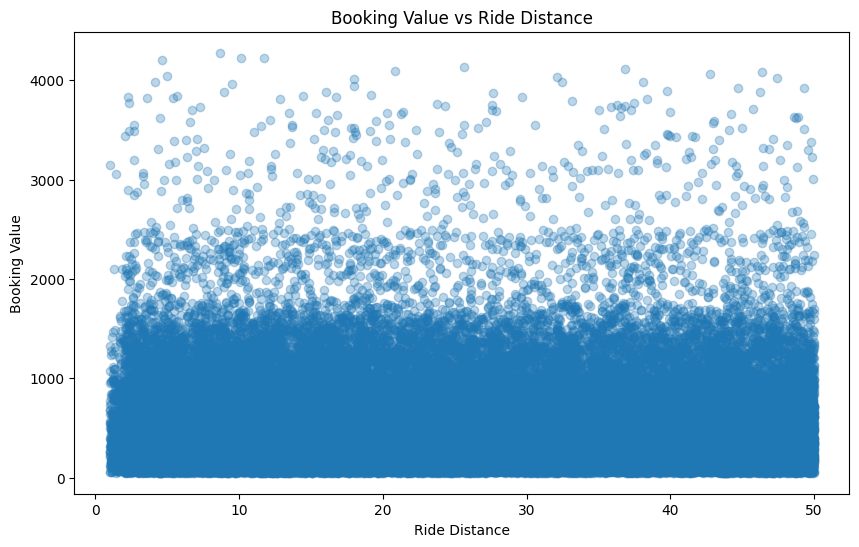

In [92]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Ride Distance"],
    df["Booking Value"],
    alpha=0.3
)

plt.title("Booking Value vs Ride Distance")
plt.xlabel("Ride Distance")
plt.ylabel("Booking Value")

plt.show()

In [93]:
df["Distance_Bin"] = pd.cut(
    df["Ride Distance"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50"]
)

df.groupby("Distance_Bin", observed=True)["Booking Value"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Distance_Bin,,,
0-10,19766,503.24,410.0
10-20,23978,508.35,414.0
20-30,19508,511.95,418.0
30-40,19500,506.93,412.0
40-50,19248,511.10,415.0


> **Insight:** - The correlation between Booking Value and Ride Distance is **0.005**, which is essentially zero.
- The scatter plot shows no visible pattern, and average booking value is flat across distance bands (₹503 to ₹512).
- In this dataset, booking value is **not driven by ride distance**. In real-world ride pricing, fares usually rise with distance, so this is worth keeping in mind when interpreting the pricing data.

### 17.2 Driver Ratings vs. Customer Rating

In [94]:
df[["Driver Ratings", "Customer Rating"]].corr()

,Driver Ratings,Customer Rating
Driver Ratings,1.00000,-0.00101
Customer Rating,-0.00101,1.00000


> **Insight:** The correlation between Driver Ratings and Customer Rating is **-0.001**, so the two ratings are unrelated.

### 17.3 Correlation matrix

In [95]:
num_cols = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT",
    "Driver Ratings",
    "Customer Rating"
]

df[num_cols].corr().round(3)

,Booking Value,Ride Distance,Avg VTAT,Avg CTAT,Driver Ratings,Customer Rating
Booking Value,1.000,0.005,0.002,0.000,-0.000,-0.000
Ride Distance,0.005,1.000,0.063,0.102,-0.002,0.005
Avg VTAT,0.002,0.063,1.000,0.062,-0.005,-0.004
Avg CTAT,0.000,0.102,0.062,1.000,0.001,0.001
Driver Ratings,-0.000,-0.002,-0.005,0.001,1.000,-0.001
Customer Rating,-0.000,0.005,-0.004,0.001,-0.001,1.000


> **Insight:** - All pairwise correlations are very weak. The largest are Ride Distance and Avg CTAT (0.102), Ride Distance and Avg VTAT (0.063), and Avg VTAT and Avg CTAT (0.062).
- Booking Value and the two ratings have correlations of about zero with every other variable.
- Pearson correlation only measures linear relationships. Even so, there is no sign of strong linear dependence among the numerical variables.

## 18. Outlier Analysis

Outliers are identified with the **IQR method**: a value is an outlier if it is below *Q1 - 1.5 × IQR* or above *Q3 + 1.5 × IQR*. Percentages are calculated on non-missing values only.

### 18.1 Outlier summary for all numerical variables

In [96]:
num_cols = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT",
    "Driver Ratings",
    "Customer Rating"
]

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    valid_count = df[col].notna().sum()
    
    outlier_summary.append([
        col,
        valid_count,
        outliers,
        round(outliers / valid_count * 100, 2)
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Variable", "Valid Values", "Outliers", "Outlier %"]
)

outlier_df

,Variable,Valid Values,Outliers,Outlier %
0,Booking Value,102000,3435,3.37
1,Ride Distance,102000,0,0.00
2,Avg VTAT,139500,0,0.00
3,Avg CTAT,102000,0,0.00
4,Driver Ratings,93000,5203,5.59
5,Customer Rating,93000,3257,3.50


### 18.2 Booking Value

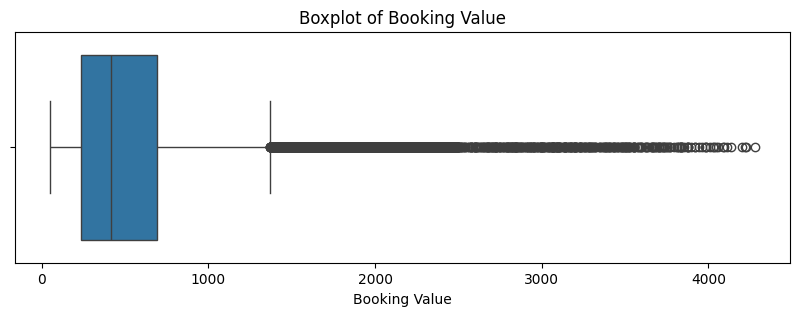

In [97]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df["Booking Value"])

plt.title("Boxplot of Booking Value")
plt.xlabel("Booking Value")

plt.show()

In [98]:
Q1 = df["Booking Value"].quantile(0.25)
Q3 = df["Booking Value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Q1: 234.0
Q3: 689.0
IQR: 455.0
Lower Bound: -448.5
Upper Bound: 1371.5


In [99]:
outliers=df[df["Booking Value"]>upper_bound]
print("No of Outliers",len(outliers))
print("Percentage of outliers:", round(len(outliers) / df["Booking Value"].notna().sum() * 100, 2), "%")

No of Outliers 3435
Percentage of outliers: 3.37 %


In [100]:
outliers["Booking Value"].describe().round(2)

count    3435.00
mean     1854.97
std       556.07
min      1372.00
25%      1474.00
50%      1620.00
75%      2097.00
max      4277.00
Name: Booking Value, dtype: float64

In [101]:
outliers[["Booking Value","Ride Distance"]].describe().round(2)

,Booking Value,Ride Distance
count,3435.00,3435.00
mean,1854.97,24.84
std,556.07,14.06
min,1372.00,1.00
25%,1474.00,12.67
50%,1620.00,23.58
75%,2097.00,37.12
max,4277.00,50.00


### 18.3 Driver Ratings

In [102]:
Q1=df["Driver Ratings"].quantile(0.25)
Q3=df["Driver Ratings"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1",Q1)
print("Q3",Q3)
print("IQR",IQR)
print("lower bound",lower_bound)
print("upper bound",upper_bound)


Q1 4.1
Q3 4.6
IQR 0.5
lower bound 3.3499999999999996
upper bound 5.35


In [103]:
outliers = df[(df["Driver Ratings"] < lower_bound) |
              (df["Driver Ratings"] > upper_bound)]

outliers_percentages = (len(outliers) / df["Driver Ratings"].notna().sum()) * 100

print("Number of outliers: ", len(outliers))
print("Percentages of Outliers: ", round(outliers_percentages, 2), "%")

Number of outliers:  5203
Percentages of Outliers:  5.59 %


In [104]:
print("lower bound",lower_bound)
print("upper bound",upper_bound)
print("Outlier Rating Distribution:")
print(df.loc[outliers.index,"Driver Ratings"].value_counts().sort_index())

lower bound 3.3499999999999996
upper bound 5.35
Outlier Rating Distribution:
Driver Ratings
3.0     745
3.1    1459
3.2    1538
3.3    1461
Name: count, dtype: int64


### 18.4 Customer Rating

In [105]:
Q1=df["Customer Rating"].quantile(0.25)
Q3=df["Customer Rating"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1",Q1)
print("Q3",Q3)
print("IQR",IQR)
print("lower bound",lower_bound)
print("upper bound",upper_bound)


Q1 4.2
Q3 4.8
IQR 0.5999999999999996
lower bound 3.3000000000000007
upper bound 5.699999999999999


In [106]:
outliers=df[(df["Customer Rating"]<lower_bound)|
    (df["Customer Rating"]>upper_bound)]
print("Number of outliers: ",len(outliers))
print("Percentages of outliers: ",(len(outliers)/df["Customer Rating"].notna().sum())*100,"%")

Number of outliers:  3257
Percentages of outliers:  3.502150537634409 %


In [107]:
outliers["Customer Rating"].value_counts().sort_index()

Customer Rating
3.0     468
3.1    1008
3.2     881
3.3     900
Name: count, dtype: int64

> **Insight:** - **Booking Value** has 3,435 outliers (3.37%), all on the high side (above ₹1,371.50). These bookings range from ₹1,372 to ₹4,277 with a mean of ₹1,854.97. Their average ride distance (24.84) is almost the same as for all rides (24.64), so high values are not explained by longer distances.
- **Driver Ratings** have 5,203 outliers (5.59%) and **Customer Rating** has 3,257 (3.50%). All of them are low ratings between 3.0 and 3.3. Ratings are limited to the 3.0 to 5.0 range, so these are genuine low ratings and not errors.
- **Ride Distance, Avg VTAT and Avg CTAT** have no outliers.
- **Treatment:** no outliers were removed. They are valid values with no sign of data-entry error. If Booking Value is used in a model later, a log transformation or an outlier-robust method would be sensible because of its strong right skew.

## 19. Key Insights

### Summary of key figures

| Metric | Result |
|---|---|
| Total bookings | 150,000 |
| Completed bookings | 62% (93,000) |
| Cancelled by driver | 18% (27,000) |
| Cancelled by customer | 7% (10,500) |
| No driver found | 7% (10,500) |
| Incomplete | 6% (9,000) |
| Booking Value | Mean ₹508.30, median ₹414, skewness 2.29 |
| Ride Distance | Mean 24.64, skewness 0.13 |
| Driver Ratings / Customer Rating | Mean 4.23 / 4.40 |
| Booking Value vs. Ride Distance correlation | 0.005 |
| Driver Ratings vs. Customer Rating correlation | -0.001 |

### Findings

**Booking outcomes and cancellations**
- Only 62% of bookings are completed. Cancellations alone account for 25% of all bookings, and **driver cancellations (18%) are about 2.6 times more frequent than customer cancellations (7%)**.
- Cancellation reasons are spread almost evenly, so no single reason explains most cancellations.
- Customer-cancelled bookings had a longer average vehicle arrival time (12.51 min) than completed ones (8.51 min).

**Demand patterns**
- Demand peaks at **10:00 and 18:00**, with the evening peak being the highest, and is lowest between 00:00 and 04:00.
- Weekdays and weekends share the same hourly pattern, and bookings per day are similar across the week.
- Monthly volume is stable (11,927 to 12,897 bookings), with no strong seasonality.

**Stability of outcomes**
- Booking outcomes are stable. Completion stays between about 61% and 63% across months, weekdays and vehicle types, and the overall cancellation rate stays within about 22% to 26% across hours of the day.
- Location-level differences exist but are based on small samples and should be treated as indicative.

**Pricing, distance and ratings**
- Booking Value is strongly right-skewed (mean ₹508.30 vs. median ₹414), while Ride Distance is nearly symmetric.
- Booking Value shows no relationship with Ride Distance (0.005) and does not vary meaningfully by vehicle type or payment method.
- Incomplete rides are much shorter (mean 10.55) than completed rides (mean 26.00).
- Driver and customer ratings are unrelated (-0.001), and low ratings (3.0 to 3.3) are the only rating outliers.

**Payments**
- UPI is the leading payment method (45.01%), and about 75% of payments are digital.

**Data quality**
- Missing values are largely structural and depend on booking status. No fully duplicated rows exist, but 1,233 Booking IDs repeat across different records.

## 20. Machine Learning Considerations

A natural modelling task from this dataset is to **predict Booking Status** (for example, completed vs. not completed). The EDA points to several important points before building such a model.

### Data leakage

A model must only use information that is available **at the time of booking**. Many columns in this dataset are recorded only after the ride has started, ended or been cancelled. Using them to predict Booking Status would cause **data leakage**: the model would appear accurate but would fail in real use.

| Variable(s) | Why it could cause leakage |
|---|---|
| `Booking Value`, `Ride Distance` | Recorded only for Completed and Incomplete rides. They are missing for cancelled and no-driver bookings, so the missing pattern reveals the outcome. |
| `Avg CTAT` | Recorded only for Completed and Incomplete rides. |
| `Payment Method` | Recorded only for Completed and Incomplete rides. |
| `Driver Ratings`, `Customer Rating` | Given after a ride, and recorded only for Completed rides. |
| `Reason for cancelling by Customer`, `Driver Cancellation Reason`, `Incomplete Rides Reason` | Directly describe the outcome. |
| `Cancelled Rides by Customer`, `Cancelled Rides by Driver`, `Incomplete Rides` | Flag columns that are effectively copies of the target. |
| `Avg VTAT` | Missing exactly when no driver was found, and it may not be known at booking time. It should be used with caution. |

### Variables that may be usable at booking time
- Time features: `Hour`, `DayOfWeek`, `Month`, `Day_Type`
- `Vehicle Type`
- `Pickup Location` and `Drop Location` (high cardinality, with 176 values each)

### Other considerations
- **Weak signal expected:** the EDA showed that outcome percentages barely change by hour, weekday, month or vehicle type. Models built only on booking-time features may therefore have limited predictive power, and this would need to be tested.
- **Class imbalance:** Completed is 62% of bookings, so a model that always predicts "Completed" would already reach 62% accuracy. Metrics such as precision, recall, F1-score (per class or macro-averaged) and a stratified train/test split are more informative than accuracy alone.
- **Problem framing:** the target can be modelled as multi-class (5 statuses) or as binary (completed vs. not completed).
- **Validation:** because bookings have timestamps, a time-based train/test split would better reflect real use than a random split.
- **Booking ID issue:** repeated Booking IDs should be resolved before modelling.
- **Skewed variables:** if Booking Value is used for another task, consider a log transformation.

## 21. Conclusion

This analysis of 150,000 Uber ride bookings shows that **only 62% of bookings are completed**. A quarter of all bookings end in a cancellation, and **driver cancellations (18%) are far more frequent than customer cancellations (7%)**.

Booking outcomes are remarkably stable. They barely change across vehicle types, months, weekdays vs. weekends or hours of the day, and cancellation reasons are spread almost evenly. Demand has a clear daily rhythm with peaks at 10:00 and 18:00, but no strong weekly or monthly trend.

Booking Value is right-skewed (mean ₹508.30, median ₹414) and is essentially unrelated to ride distance, vehicle type or payment method. Ratings average 4.23 (driver) and 4.40 (customer) and are unrelated to each other. Missing values are structural and reflect how each booking ended, and no outliers were removed because none appear to be errors.

**Limitations**
- The EDA is descriptive, so associations should not be read as causes.
- Many patterns are very uniform across categories, so the dataset offers limited variation for explaining why bookings fail. Validation with additional data sources would strengthen the conclusions.
- Location and route-level results rest on small samples.
- Repeated Booking IDs should be confirmed with the data owner.

**Suggested next steps**
- Investigate the drivers of driver cancellations, the largest source of failed bookings, with additional operational data.
- Study supply and demand around the 10:00 and 18:00 peaks.
- If a predictive model is built, use only booking-time features and avoid the leakage risks listed in Section 20.